Quantum Amplitude Estimation (QAE) https://qiskit-community.github.io/qiskit-finance/tutorials/00_amplitude_estimation.html for finance problems.  Bernoulli success probability = p, failure = 1-p.  This will become Grover's algorithm.

Having trouble with tutorial because it is for qiskit 1.0.1 and we are on qiskit 2.3

In [1]:
p = 0.2

In [2]:
import numpy as np
from qiskit.circuit import QuantumCircuit


class BernoulliA(QuantumCircuit):
    """A circuit representing the Bernoulli A operator."""

    def __init__(self, probability):
        super().__init__(1)  # circuit on 1 qubit

        theta_p = 2 * np.arcsin(np.sqrt(probability))
        self.ry(theta_p, 0)

class BernoulliQ(QuantumCircuit):
    """A circuit representing the Bernoulli Q operator."""

    def __init__(self, probability):
        super().__init__(1)  # circuit on 1 qubit

        self._theta_p = 2 * np.arcsin(np.sqrt(probability))
        self.ry(2 * self._theta_p, 0)

    def power(self, k):
        # implement the efficient power of Q
        q_k = QuantumCircuit(1)
        q_k.ry(2 * k * self._theta_p, 0)
        return q_k

In [3]:
A = BernoulliA(p)
Q = BernoulliQ(p)

In [4]:
from qiskit_algorithms import EstimationProblem

problem = EstimationProblem(
    state_preparation=A,  # A operator
    grover_operator=Q,  # Q operator
    objective_qubits=[0],  # the "good" state Psi1 is identified as measuring |1> in qubit 0
)

In [15]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

qiskit_runtime_service.__init__:WARNING:2026-03-16 15:35:04,528: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-16 15:35:05,135: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-16 15:35:09,528: Using instance: open-instance, plan: open


<IBMBackend('ibm_marrakesh')>


In [23]:
from qiskit_algorithms import AmplitudeEstimation

# This specific hardware stuff was not in the original tutorial.  Also added the transpiler option.  Got these things from the QAOA example
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

# This is in the original tutorial
ae = AmplitudeEstimation(
    num_eval_qubits=3,  # the number of evaluation qubits specifies circuit width and accuracy
    sampler=sampler,
    transpiler=pm
)

In [24]:
circuit = ae.construct_circuit(problem)

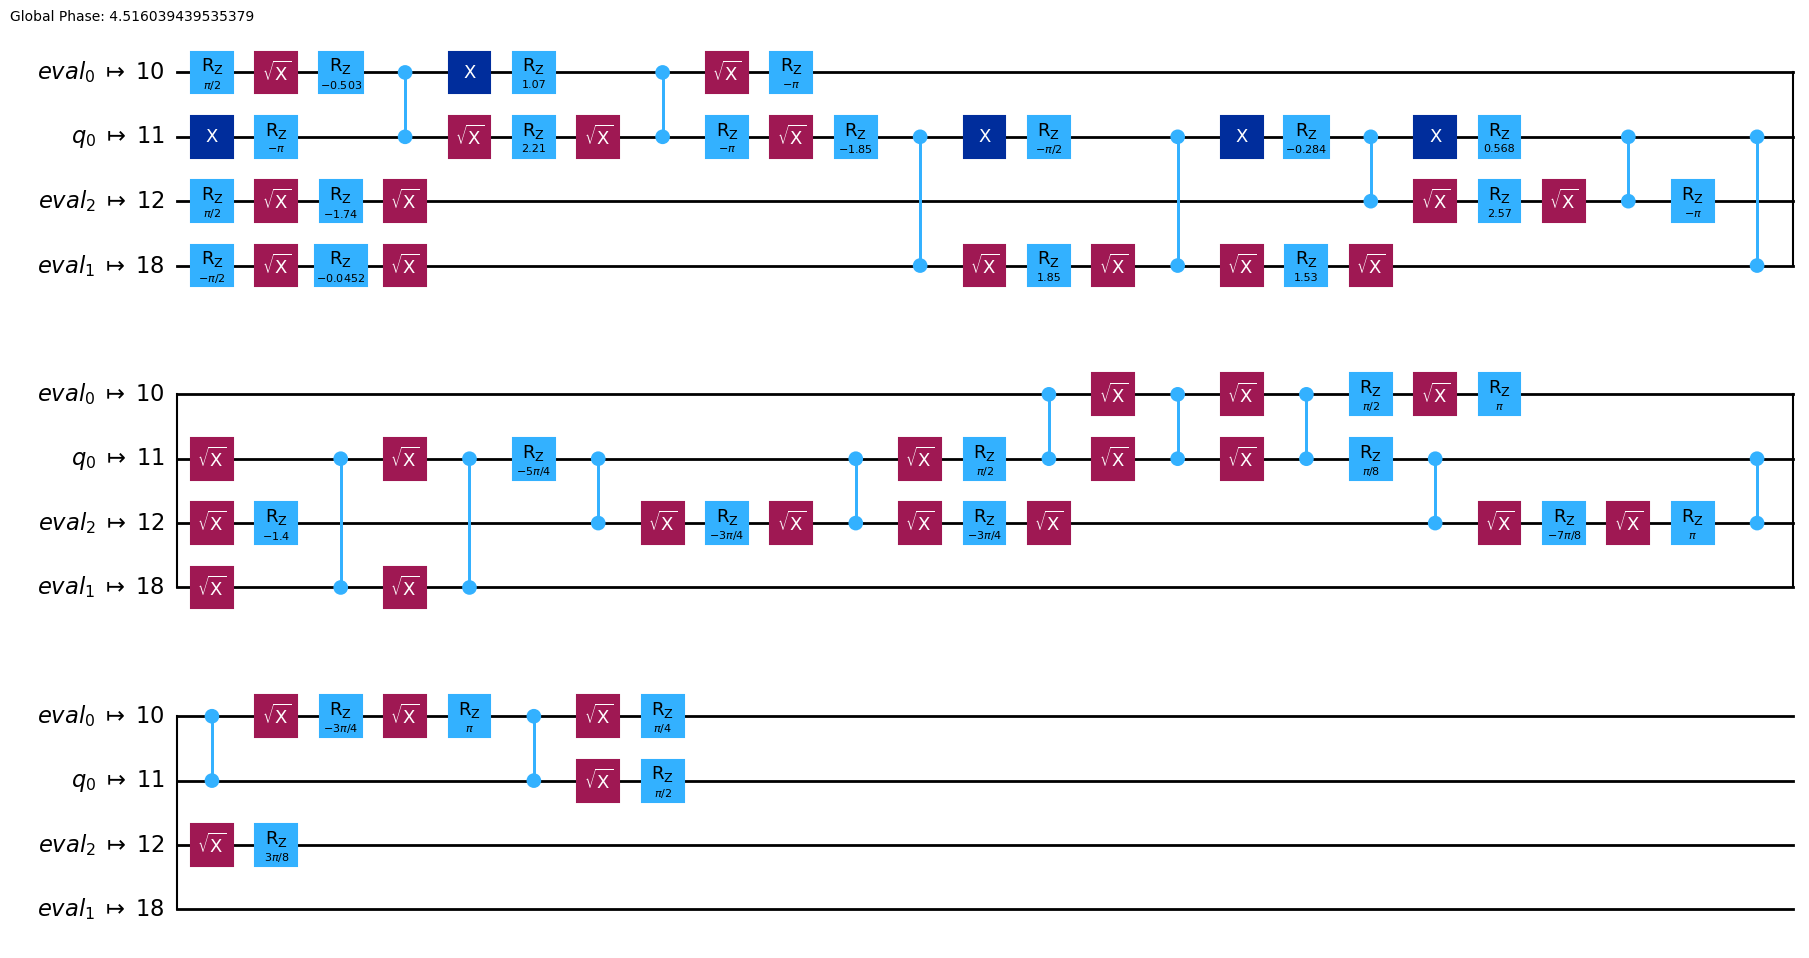

In [25]:
circuit.draw("mpl")

In [26]:
ae_result = ae.estimate(problem)

KeyError: 'shots'

In [27]:
# Wasting time on my account!
ae_circuit = ae.construct_circuit(problem)
ae_circuit.decompose().draw(
    "mpl", style="clifford"
)  # decompose 1 level: exposes the Phase estimation circuit!